# Visualizations for Bike Rental Patterns 

In [ ]:
# Import necessary libraries
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.axes import Axes

# 1) Load data
df_viz = pd.read_csv("../data/processed/hour_clean.csv")

# Create a DF for the visualizations
by_hour = df_viz.copy()


# Definition of a dictionnary with days that we'll use later
day_dict = { 0 : 'Sunday',
              1: 'Monday',
              2: 'Tuesday',
              3: 'Wednesday',
              4: 'Thursday',
              5: 'Friday',
              6: 'Saturday'}

# Creation of a 'day_label' column
by_hour['day_label'] = by_hour['weekday'].map(day_dict)


# What we know from the Random Forest Model
In almost every run of the dataset the most important features are(descendent):

+ Hour of day
+ Temperature/feeling temperature
+ Working day indicator
+ Weather and humidity

**Conclussion: Bike rental demand is primarily driven by human routines, not weather.** 

# Peak Times by Day



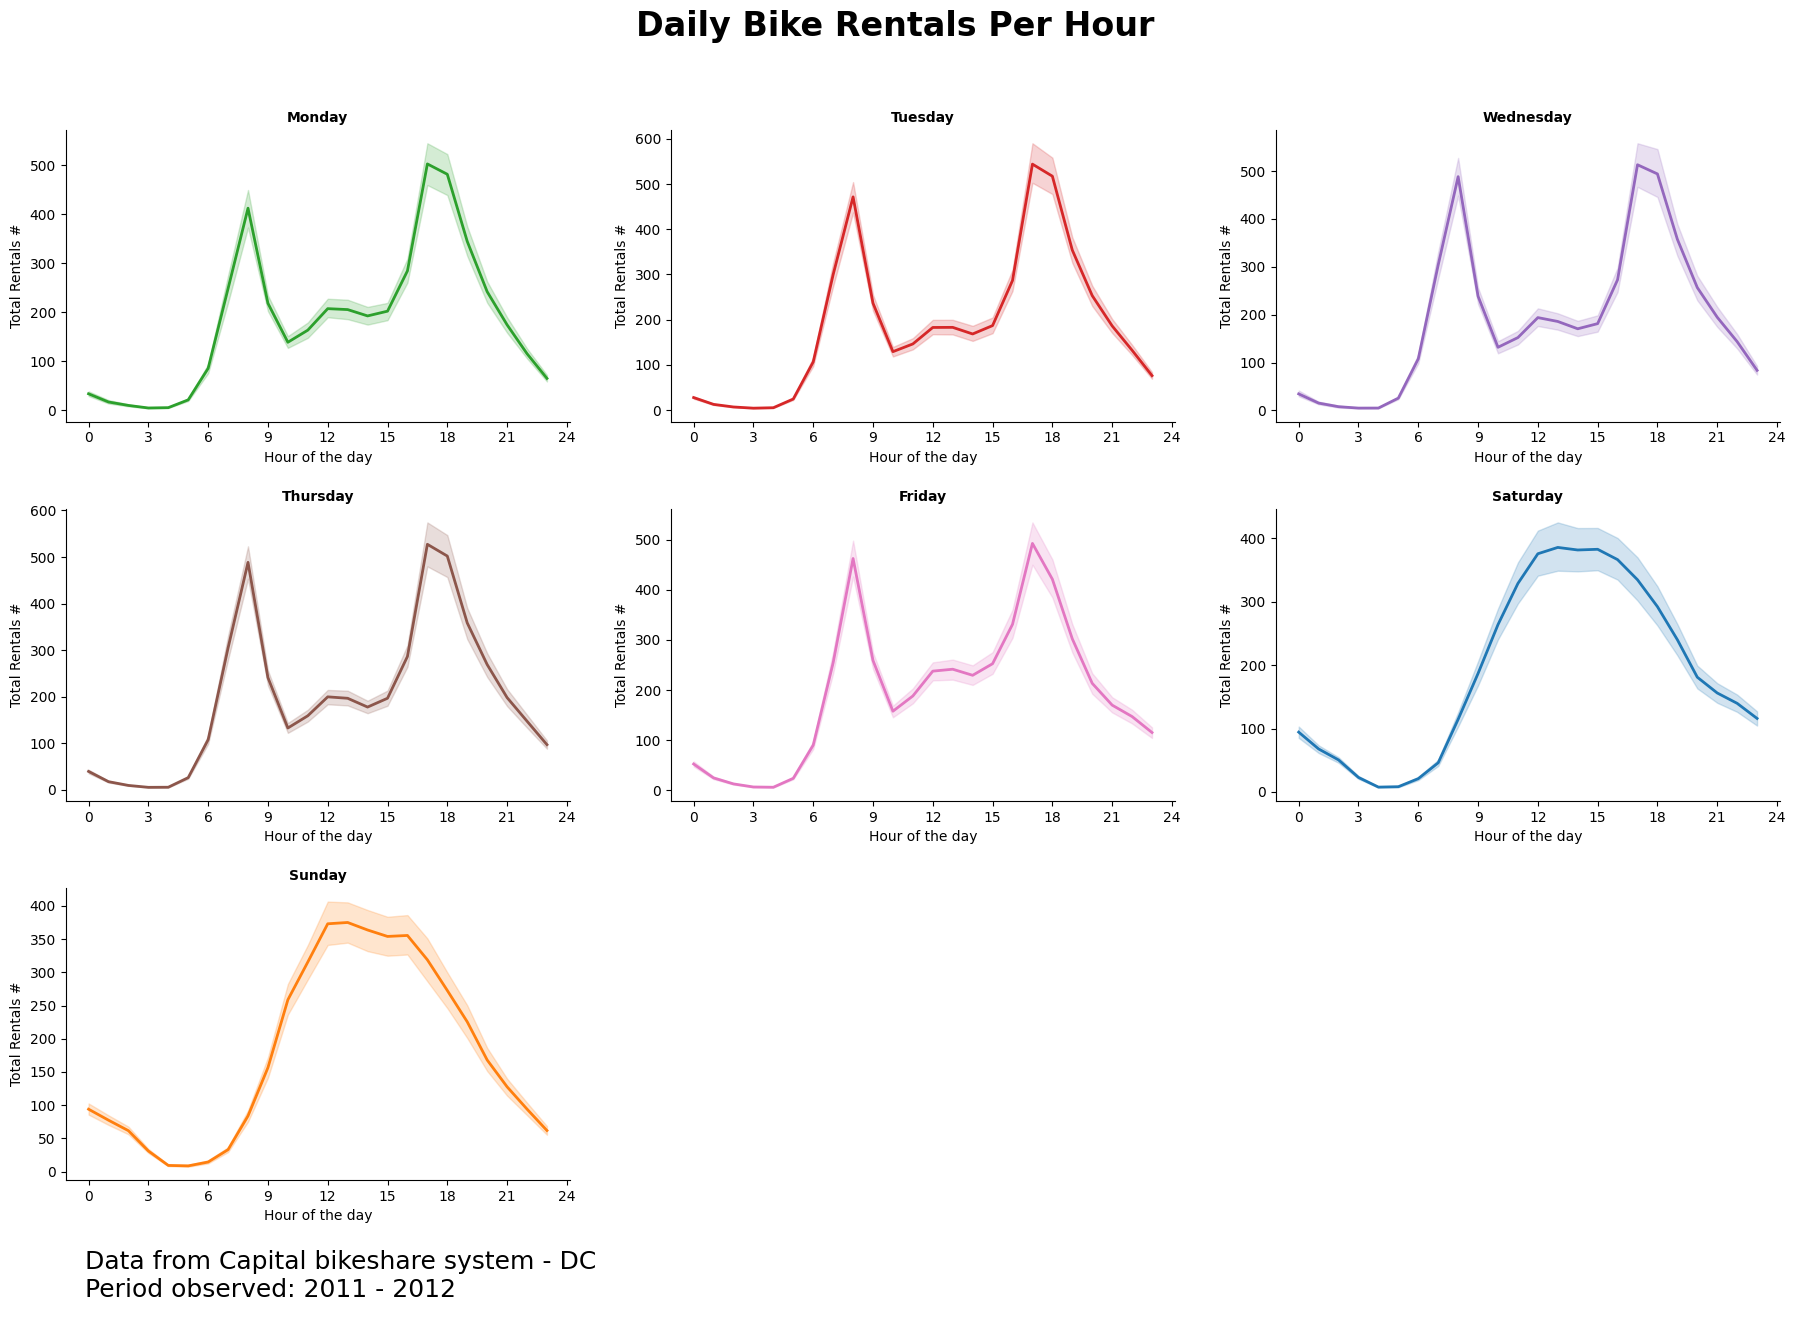

In [80]:
#Creation of visualization #1
# Number of rentals per hour to understand peak timings by day 


# Order for subplots
desired_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Visualization configuration
daysplot = sns.relplot(
    data = by_hour,
    x='hr',
    y='cnt',
    hue = 'day_label', # Using the day of the week column for color.
    col = 'day_label', # Creation of graphs per day
    col_order= desired_order,
    kind = 'line', # Type of graphs created
    col_wrap = 3 , # Number of columns to show graphs.
    legend = False,
    height= 5,
    aspect=1.2 ,
    linewidth=2 ,
    facet_kws={'sharex': False, 'sharey': False}
)

# Labels
daysplot.set_titles( template= "{col_name}",fontweight='bold', fontsize=28)
daysplot.set(ylabel = "Total Rentals #",
              xlabel= "Hour of the day")
daysplot.set(xticks=[0, 3, 6, 9, 12, 15, 18,21,24])

# Title
daysplot.fig.suptitle('Daily Bike Rentals Per Hour', fontsize=24, fontweight='bold')
daysplot.fig.subplots_adjust(top=0.9)

#Annotation
note =  f"""
Data from Capital bikeshare system - DC
Period observed: 2011 - 2012
"""

plt.figtext(0.05, 0.1, note, 
            ha="left", fontsize=18, va="bottom")

# Adjust layout to prevent clipping
plt.subplots_adjust(bottom=0.2) 
daysplot.fig.subplots_adjust(wspace=0.2, hspace=0.3)

# Save the plot
plt.savefig('daily_bike_rentas_per_hour.png')

# Display the plot
plt.show()

## Observation

This chart shows the overall pattern of bike rentals. Rentals generally peak on weekdays between 7 a.m. and 9 a.m., and again between 5 p.m. and 7 p.m. In contrast, the weekend trend is different, with rental activity occurring at times that more closely align with when people typically schedule leisure activities. This suggests that a significant portion of registered users rely on bikes for commuting to and from work during the week, while weekend usage is more related to recreational purposes. 🚲📊

# Peak Times by Season


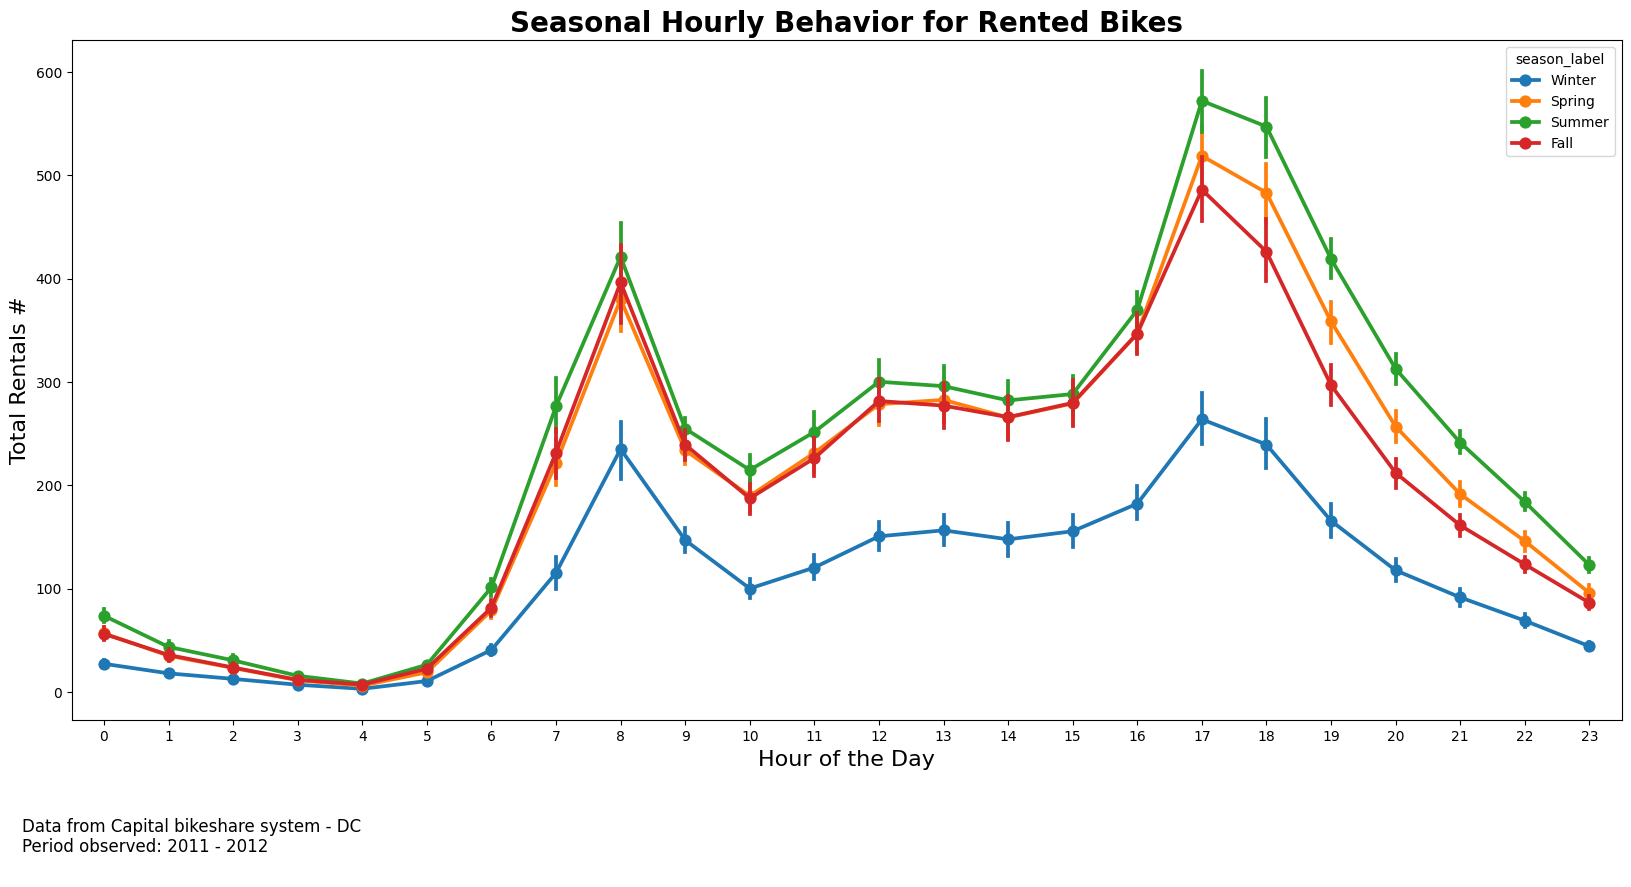

In [81]:
# Creation of visualization #2
# Number of rentals per hour to understand peak timings by season 


fig, ax = plt.subplots(figsize=(20, 10)) 
sns.pointplot(data=by_hour, x='hr', y='cnt', hue='season_label', ax=ax) 
ax.set_title('Seasonal Hourly Behavior for Rented Bikes', size=20, fontweight='bold')   # Set the title for the plot 
ax.set_xlabel('Hour of the Day', size=16 )  # Set the x-axis label 
ax.set_ylabel('Total Rentals #', size =16)  # Set the y-axis label 
fig.subplots_adjust(bottom=0.2)

# Add the note using fig.text()
fig.text(0.1, 0.05, 
         note,  
         wrap=True,  # Allows the text to wrap within the figure width
         horizontalalignment='left', # Centers the text at x=0.5
         fontsize=12,
         ) # Optional text box


# Save the plot
plt.savefig('seasonal_bike_rentas_per_hour.png')

# Display the plot
plt.show()

## Observation

This chart shows the overall pattern of bike rentals during different seasons in a year. Rentals peak times are continuos with the previous visualization. 
The pattern remains consistent throughout the year. However, there are slight decreases in rentals during the winter months, while the highest rental volumes are typically observed during the summer. 🚲📊

# Effect of Temperature on Bike Rental Behaviors


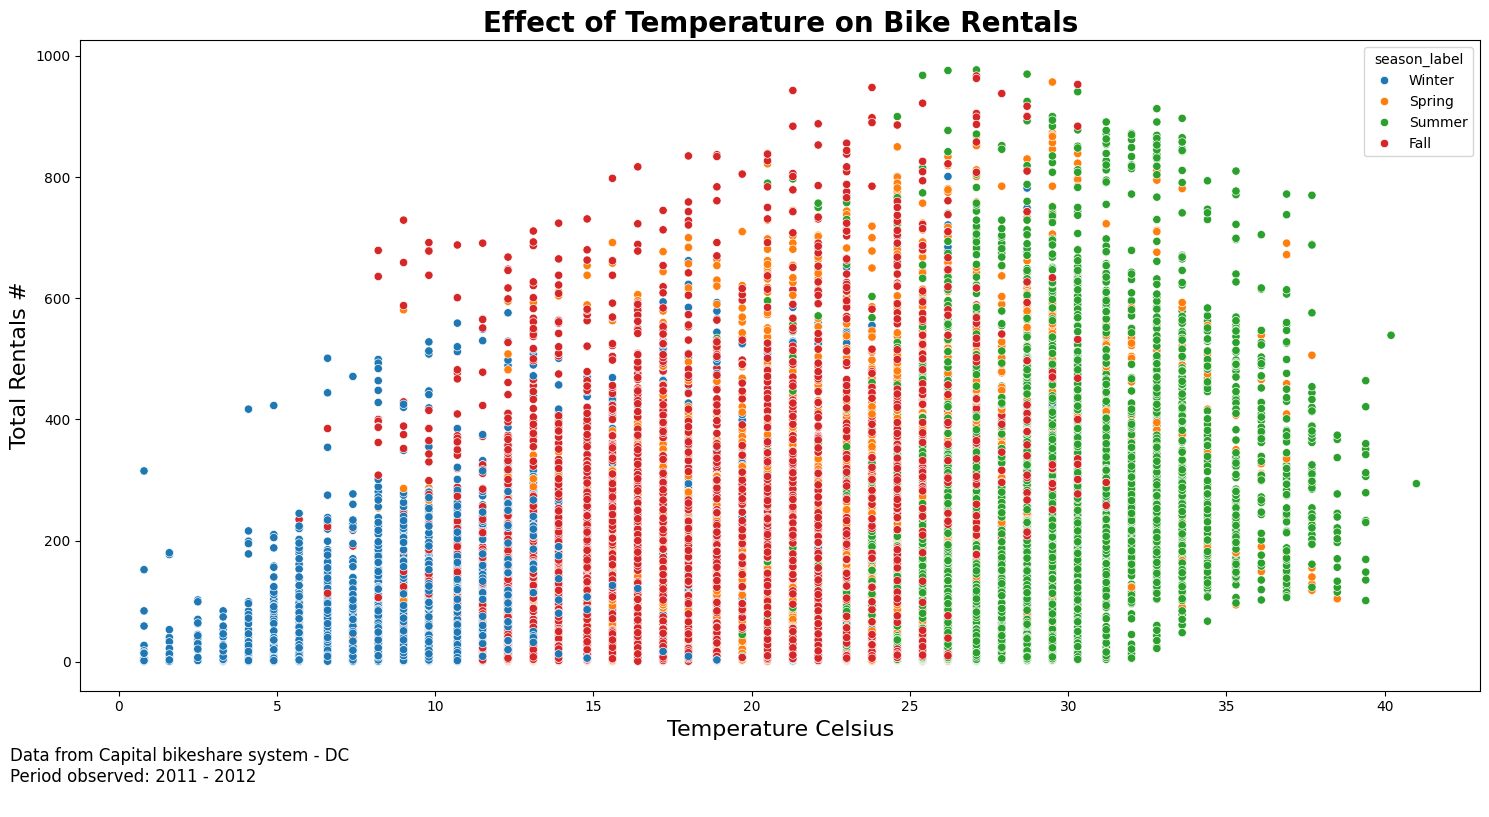

In [ ]:
# Creation of visualization #3
# Effect of temperature on bike rentals represented by season.

plt.figure(figsize=(15, 8)) 

sns.scatterplot(x='temp_celsius', y='cnt', data=by_hour, hue='season_label',  legend=True) 
plt.xlabel('Temperature Celsius',  size =16)  
plt.ylabel('Total Rentals #' , size =16)  
plt.title('Effect of Temperature on Bike Rentals', size=20, fontweight='bold')  

# Add a bottom note
plt.figtext(0.01, -0.01, note, 
            ha="left", fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 1]) # Adjust layout to make room


# Save the plot
plt.savefig('temperature_effect_rentals.png')

# Display the plot
plt.show()



## Observations
As temperatures rise, the number of bike rentals tends to increase as well, showing a clear relationship between warmer weather and higher usage; however, most rentals occur during the spring and fall seasons, suggesting that people prefer engaging in outdoor physical activities during milder weather conditions rather than during the extreme heat of summer days. 🚲🌤️

# Conclussions


Based on the insights obtained from the analysis, several practical recommendations can be proposed to help improve and optimize the bike-sharing service.

- **Improving availability during peak hours:** The company should ensure that a sufficient number of bikes are available during the main commuting periods on weekdays, particularly between 7 a.m. and 9 a.m. and from 5 p.m. to 7 p.m. Demand is highest during these hours, mainly from users who rely on the service for transportation to and from work.

- **Promotions aimed at casual riders:** Marketing strategies could focus on attracting casual users during the times when their activity is highest, such as weekends and midday hours between 12 p.m. and 5 p.m. Targeted promotions, discounts, or short-term offers during these periods could help increase ridership.

- **Seasonal planning:** Since the analysis shows that demand tends to peak during the spring and fall seasons, the company should consider increasing the number of bikes and docking stations available during this time. 